# 01 — Data collection: Truth Social posts

Doel: lokale dump opbouwen van Donald Trump's Truth Social posts sinds februari 2022.

**Drie kanalen, in volgorde van voorkeur:**

| Kanaal | Pro | Con |
|---|---|---|
| Lokale archive (Kaggle / trumpstruth.org) | Stabiel, geen auth | Niet altijd up-to-date |
| `truthbrush` (Stanford IO) | Live data, alle metadata | Vereist Truth Social login, ToS-grijszone |
| Synthetic fallback | Werkt offline | Niet bruikbaar voor finale resultaten |

**Strategie**: download eerst een complete Kaggle dump (stabiel) voor de bulk
historische data, dan eventueel `truthbrush` voor de laatste dagen.

De loader-functie `fetch_posts_archive()` zit in `src/data/collect_truthsocial.py` en
ondersteunt zowel **truthbrush** kolomnamen (`favourites_count`, `reblogs_count`,…)
als **Kaggle** schema (`like_count`, `retruth_count`, `reply_count`).


In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.collect_truthsocial import fetch_posts_archive

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas={pd.__version__}, numpy={np.__version__}")

pandas=2.2.3, numpy=2.1.3


## Optie A — `truthbrush` (live scraper)

Setup als je live data wilt aanvullen:

```bash
pip install truthbrush
export TRUTHSOCIAL_USERNAME=<jouw_login>
export TRUTHSOCIAL_PASSWORD=<jouw_password>
```

⚠️ Maak een **wegwerp-account** aan, niet je persoonlijke. Truth Social kan accounts bannen
voor scraping. Voor academisch gebruik is dit verdedigbaar maar vermeld het netjes
in je methodologie.


In [2]:
def fetch_posts_truthbrush(user: str = "realDonaldTrump", created_after: str | None = None) -> pd.DataFrame:
    """Wrapper rond truthbrush. Vereist env vars TRUTHSOCIAL_USERNAME en TRUTHSOCIAL_PASSWORD."""
    if not (os.getenv("TRUTHSOCIAL_USERNAME") and os.getenv("TRUTHSOCIAL_PASSWORD")):
        raise RuntimeError("Set TRUTHSOCIAL_USERNAME en TRUTHSOCIAL_PASSWORD eerst.")
    from truthbrush.api import Api
    api = Api()
    statuses = api.pull_statuses(username=user, created_after=created_after, replies=False)
    rows = [{
        "post_id": s.get("id"),
        "timestamp_utc": s.get("created_at"),
        "text": s.get("content", ""),
        "favorites": s.get("favourites_count", 0),
        "reposts": s.get("reblogs_count", 0),
        "replies": s.get("replies_count", 0),
        "url": s.get("url"),
    } for s in statuses]
    df = pd.DataFrame(rows)
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    return df.sort_values("timestamp_utc").reset_index(drop=True)

## Optie C — synthetic fallback (offline testing)

Voor offline iteratie en als de echte source faalt. Niet bruikbaar voor finale resultaten.


In [3]:
TOPIC_VOCAB = {
    "trade": ["tariffs are working great", "China is paying us billions in tariffs",
              "the trade deal will be massive", "we need fair trade not free trade"],
    "fed": ["the Fed should cut rates immediately", "Powell is way behind the curve",
            "interest rates are too high", "we have no inflation thanks to my policies"],
    "energy": ["drill baby drill", "we need cheap energy for American families",
               "Saudi Arabia must increase oil production", "OPEC playing games with oil prices"],
    "election": ["the polls look fantastic", "tremendous rally tonight massive crowds",
                 "the radical left is destroying our country", "Make America Great Again"],
    "economy": ["best economy in history", "stock market hitting all time highs",
                "jobs jobs jobs", "GDP growth is incredible", "inflation is being defeated"],
    "media": ["fake news media wont report this", "CNN ratings have collapsed",
              "the failing New York Times strikes again", "media is the enemy of the people"],
}


def synthesize_posts(n_days: int = 1500, posts_per_day_lambda: float = 12.0,
                     start_date: str = "2022-02-21", seed: int = 42) -> pd.DataFrame:
    """Plausibele posts genereren — alleen voor offline testing."""
    rng = np.random.default_rng(seed)
    start = pd.Timestamp(start_date, tz="UTC")
    rows = []
    for day_offset in range(n_days):
        date = start + pd.Timedelta(days=day_offset)
        n_posts = rng.poisson(posts_per_day_lambda)
        for _ in range(n_posts):
            topic = rng.choice(list(TOPIC_VOCAB.keys()))
            phrases = rng.choice(TOPIC_VOCAB[topic], size=rng.integers(1, 4), replace=True)
            text = ". ".join(phrases).capitalize() + "!"
            hour = int(rng.integers(0, 24))
            timestamp = date.replace(hour=hour, minute=int(rng.integers(0, 60)))
            rows.append({"post_id": f"synth_{len(rows):07d}", "timestamp_utc": timestamp,
                         "text": text, "favorites": int(rng.lognormal(9, 1.5)),
                         "reposts": int(rng.lognormal(7, 1.5)), "replies": int(rng.lognormal(7, 1.5)),
                         "url": f"https://example.synthetic/post/{len(rows)}"})
    df = pd.DataFrame(rows)
    df.attrs["source"] = "synthetic"
    return df.sort_values("timestamp_utc").reset_index(drop=True)

## Main: collection orchestrator

Probeer in deze volgorde: archive → truthbrush → synthetic.


In [4]:
ARCHIVE_PATH = Path("../data/raw/trump_truth_archive.csv")


def collect() -> pd.DataFrame:
    if ARCHIVE_PATH.exists() and ARCHIVE_PATH.stat().st_size > 1000:
        print(f"→ Loading from archive: {ARCHIVE_PATH}")
        df = fetch_posts_archive(ARCHIVE_PATH)
        df.attrs["source"] = "kaggle_archive"
        return df

    if os.getenv("TRUTHSOCIAL_USERNAME") and os.getenv("TRUTHSOCIAL_PASSWORD"):
        try:
            print("→ Fetching live via truthbrush…")
            df = fetch_posts_truthbrush()
            df.attrs["source"] = "truthbrush"
            return df
        except Exception as e:
            print(f"!!! truthbrush failed: {type(e).__name__}: {e}")

    print("→ Geen live source beschikbaar — fallback op synthetic data.")
    return synthesize_posts()


posts = collect()
print(f"\nSource:     {posts.attrs.get('source', 'unknown')}")
print(f"Shape:      {posts.shape}")
print(f"Date range: {posts['timestamp_utc'].min()} → {posts['timestamp_utc'].max()}")
posts.head(3)

→ Loading from archive: ../data/raw/trump_truth_archive.csv

Source:     kaggle_archive
Shape:      (26819, 40)
Date range: 2022-02-14 15:54:32.528000+00:00 → 2026-04-23 03:02:45.507000+00:00


/Users/quintenfriederichs/code/truthsocial-marketimpact/src/data/collect_truthsocial.py:65: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,post_id,timestamp_utc,text,url,reposts,favorites,replies,engagement_ratio,is_retruth,hour_of_day,...,countries_mentioned,companies_mentioned,mentions_person,toxicity_score,topic,rhetorical_device,target_entity,sentiment_toward_target,is_policy_related,has_text
0,107797156496908384,2022-02-14 15:54:32.528000+00:00,Get Ready! Your favorite President will see y...,https://truthsocial.com/@realDonaldTrump/10779...,49001,264075,33994,0.7609,False,15,...,[],[],[],0.0015,Personal,Boast,NaN,positive,False,True
1,108211822140637685,2022-04-28 21:29:28.207000+00:00,I’M BACK! #COVFEFE,https://truthsocial.com/@realDonaldTrump/10821...,123196,410837,60886,0.6906,False,21,...,[],"[""I\u2019M BACK""]",[],0.0145,Personal,Boast,NaN,positive,False,True
2,108217783188791701,2022-04-29 22:45:26.592000+00:00,Thank you to all of the GREAT and BEAUTIFUL Am...,https://truthsocial.com/@realDonaldTrump/10821...,47614,217254,19641,0.7636,False,22,...,"[""Truth""]","[""Haters"", ""Social Media"", ""BEAUTIFUL"", ""GREAT...",[],0.0009,Media,Praise,Truth Social,positive,False,True


## Data quality checks


In [5]:
print("--- Dtypes ---")
print(posts.dtypes)
print()
print("--- Missing values per kolom ---")
print(posts.isna().sum())
print()
print("--- Duplicate post_ids ---")
print(f"  {posts['post_id'].duplicated().sum()}")
print()
print("--- Timestamps monotonic? ---")
print(f"  {posts['timestamp_utc'].is_monotonic_increasing}")

--- Dtypes ---
post_id                                  int64
timestamp_utc              datetime64[ns, UTC]
text                                    object
url                                     object
reposts                                  int64
favorites                                int64
replies                                  int64
engagement_ratio                       float64
is_retruth                                bool
hour_of_day                              int64
day_of_week                             object
is_weekend                                bool
days_since_last_post                   float64
sentiment_score                        float64
sentiment_label                         object
emotion                                 object
readability_score                      float64
word_count                             float64
cap_ratio                              float64
all_caps_word_count                    float64
exclamation_count                      float6

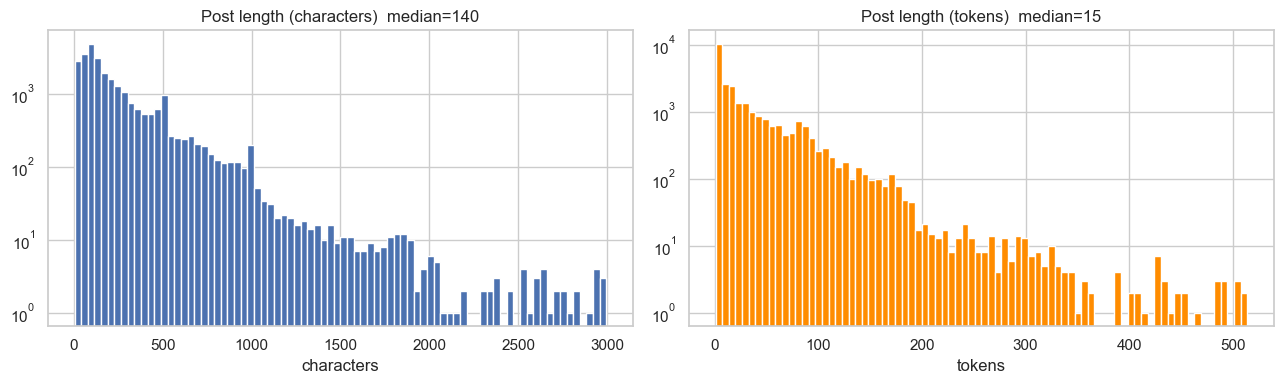

Posts < 5 tokens:   8,908  (33.2%)
Posts > 100 tokens: 2,174  (8.1%)


In [6]:
# Tekstlengte distributie (na het droppen van text=NaN posts in de loader)
posts["n_chars"] = posts["text"].str.len()
posts["n_tokens"] = posts["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(posts["n_chars"], bins=80, edgecolor="white")
axes[0].set_title(f"Post length (characters)  median={posts['n_chars'].median():.0f}")
axes[0].set_xlabel("characters")
axes[0].set_yscale("log")

axes[1].hist(posts["n_tokens"], bins=80, edgecolor="white", color="darkorange")
axes[1].set_title(f"Post length (tokens)  median={posts['n_tokens'].median():.0f}")
axes[1].set_xlabel("tokens")
axes[1].set_yscale("log")
fig.tight_layout()
plt.show()

print(f"Posts < 5 tokens:   {(posts['n_tokens'] < 5).sum():,}  ({(posts['n_tokens'] < 5).mean()*100:.1f}%)")
print(f"Posts > 100 tokens: {(posts['n_tokens'] > 100).sum():,}  ({(posts['n_tokens'] > 100).mean()*100:.1f}%)")

## Volume over tijd


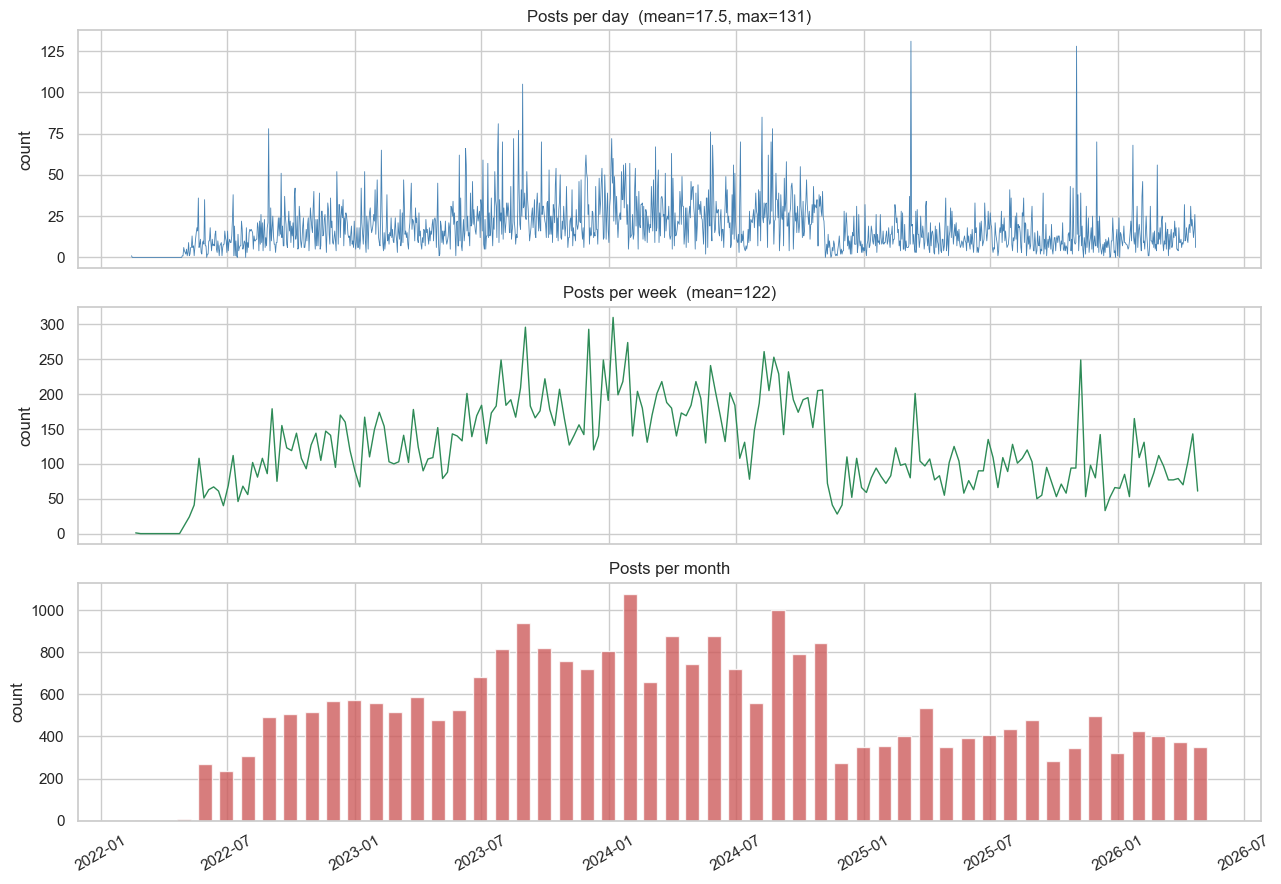

In [7]:
posts_per_day = posts.set_index("timestamp_utc").resample("D").size().rename("n_posts")
posts_per_week = posts.set_index("timestamp_utc").resample("W").size().rename("n_posts")
posts_per_month = posts.set_index("timestamp_utc").resample("ME").size().rename("n_posts")

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(posts_per_day.index, posts_per_day.values, linewidth=0.6, color="steelblue")
axes[0].set_title(f"Posts per day  (mean={posts_per_day.mean():.1f}, max={posts_per_day.max()})")
axes[0].set_ylabel("count")

axes[1].plot(posts_per_week.index, posts_per_week.values, linewidth=1.0, color="seagreen")
axes[1].set_title(f"Posts per week  (mean={posts_per_week.mean():.0f})")
axes[1].set_ylabel("count")

axes[2].bar(posts_per_month.index, posts_per_month.values, width=20, color="indianred", alpha=0.8)
axes[2].set_title("Posts per month")
axes[2].set_ylabel("count")
axes[2].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

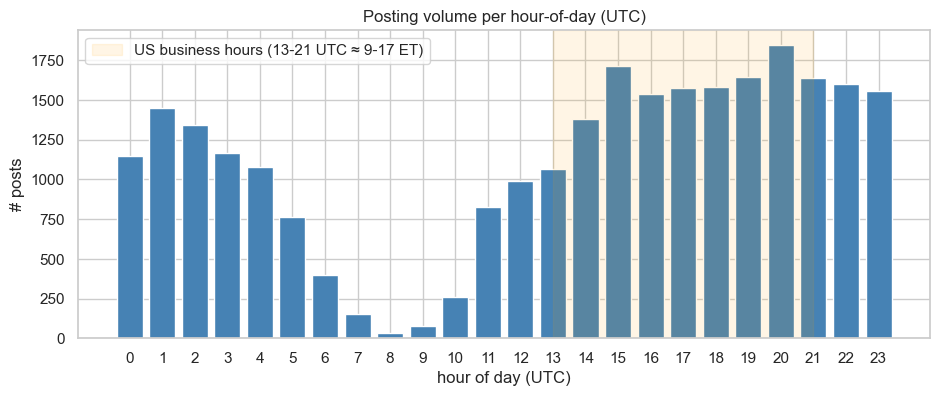

In [8]:
# Posting hour distributie (UTC)
hour_dist = posts["timestamp_utc"].dt.hour.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hour_dist.index, hour_dist.values, color="steelblue", edgecolor="white")
ax.set_title("Posting volume per hour-of-day (UTC)")
ax.set_xlabel("hour of day (UTC)")
ax.set_ylabel("# posts")
ax.set_xticks(range(0, 24))
ax.axvspan(13, 21, alpha=0.1, color="orange", label="US business hours (13-21 UTC ≈ 9-17 ET)")
ax.legend()
plt.show()

## Vocabulary preview

Top-30 woorden na simpele stopwords-filter. Niet voor productie — voor de echte
TF-IDF zie notebook 04.


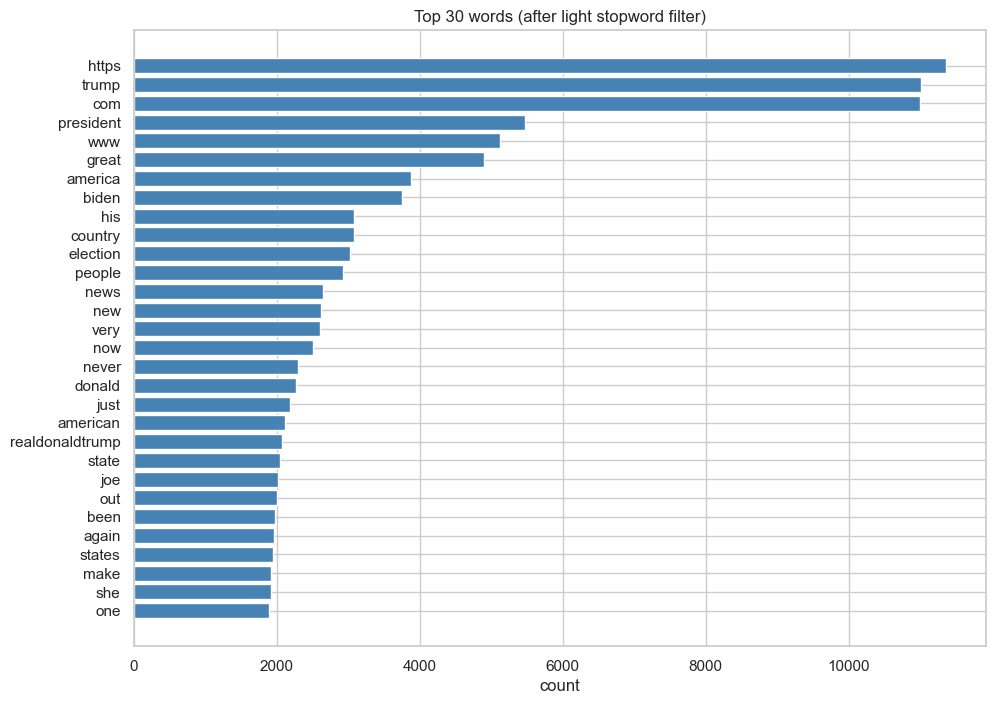

,word,count
0,https,11361
1,trump,11011
2,com,10995
3,president,5479
4,www,5121
5,great,4892
6,america,3880
7,biden,3757
8,his,3080
9,country,3073


In [9]:
STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has", "have",
    "i", "in", "is", "it", "its", "of", "on", "or", "our", "so", "that", "the",
    "this", "to", "was", "were", "will", "with", "you", "your", "we", "us", "they",
    "them", "their", "but", "not", "no", "do", "does", "did", "if", "all", "my",
    "me", "im", "ive", "youre", "thats", "its", "dont", "wont", "would", "could",
    "should", "what", "when", "where", "who", "how", "which", "than", "then",
}

from collections import Counter
import re

words = []
for t in posts["text"].str.lower():
    tokens = re.findall(r"[a-z]+", str(t))
    words.extend(w for w in tokens if w not in STOPWORDS and len(w) > 2)

word_counts = Counter(words)
top30 = word_counts.most_common(30)
top_df = pd.DataFrame(top30, columns=["word", "count"])

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top_df["word"][::-1], top_df["count"][::-1], color="steelblue")
ax.set_title("Top 30 words (after light stopword filter)")
ax.set_xlabel("count")
plt.show()
top_df.head(15)

## Save processed


In [10]:
out_path = Path("../data/raw/posts.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)

# Drop temporary EDA columns
to_save = posts.drop(columns=["n_chars", "n_tokens"], errors="ignore")
# Keep only canonical schema kolommen (eventuele bonus Kaggle features droppen voor cleanliness)
canonical = ["post_id", "timestamp_utc", "text", "favorites", "reposts", "replies", "url"]
to_save = to_save[[c for c in canonical if c in to_save.columns]]

to_save.to_parquet(out_path, index=False)
print(f"Wrote {len(to_save):,} posts to {out_path.resolve()}")
print(f"Source: {posts.attrs.get('source', 'unknown')}")
print(f"Columns: {list(to_save.columns)}")

Wrote 26,819 posts to /Users/quintenfriederichs/code/truthsocial-marketimpact/data/raw/posts.parquet
Source: kaggle_archive
Columns: ['post_id', 'timestamp_utc', 'text', 'favorites', 'reposts', 'replies', 'url']


## Bevindingen & next steps

**Wat we nu hebben** (echte Kaggle data):
- 26.819 posts met text (32.754 totaal, 5.935 media-only zonder text gedropt).
- Datumrange: 14 feb 2022 → 23 april 2026.
- Volledige metadata: timestamps, engagement counts, URLs.

**Volgende stap (notebook 03 — alignment):**
- Posts joinen aan marktbewegingen via `merge_asof`.
- Compute abnormal returns voor S&P 500 en WTI per post per window.
- Output: `data/processed/aligned.parquet`.

**Open vragen voor begeleider:**
- Truth Social weekend posts: alignen naar maandag open of skipen?
- Posts met enkel een link/image (text < 5 tokens) excluden?
- Sub-periode analyse: presidentschap (jan 2025+) vs. campagne (2022-2024)?
